# Modelo de K-Means

### ¿Qué es?

* `K-Means` es uno de los algoritmos de ***machine learning no supervisado*** más usados para tareas de `clustering (agrupamiento)`.
* Es un algoritmo que `agrupa un conjunto de datos en K grupos (clusters)` en función de su similitud.
* No necesita etiquetas previas; sólo los datos y el número de clusters que quieres formar (K).
* Cada cluster se representa con su centroide (el "promedio" de todos los puntos en el grupo).
* ¿Cómo funciona K-Means?
  - Elegir K: Definir el número de clusters que se quieren formar.
  - Inicialización de centroides: Se seleccionan aleatoriamente K puntos del dataset como centroides iniciales.
  - Asignación de puntos a los clusters: Cada dato se asigna al centroide más cercano (generalmente usando `distancia euclidiana`).
  - Recalcular centroides: Para cada cluster, se calcula el nuevo centroide como el promedio de los puntos que contiene.
  - Repetir asignación y actualización: Se repiten los 2 pasos anteriores hasta que:Los centroides dejan de cambiar significativamente o se alcanza un número máximo de iteraciones.
* `K-Means` busca minimizar la suma de las distancias cuadradas entre cada punto y su centroide (también llamado *inertia* o *within-cluster sum of squares*).
* Ventajas:
  - Simple y rápido (bueno para grandes volúmenes de datos).
  - Fácil de interpretar.
* Desventajas:
  - Hay que definir K previamente.
  - Sensible a valores atípicos (outliers).
  - Funciona mejor con clusters esféricos y de tamaño similar.

### Ejemplo

* En este caso la 'K' a nivel negocio podría representar distintas cosas, como por ejemplo, un tipo de producto dado el tipo de cliente etc.
* Primeramente se inicia estableciendo ***"K Centroides"*** de forma aleatoria, recordemos que en este tipo de modelo es no supervisado, por lo que no tiene como referencia una variable objetivo.
  
![CentroidesRandom.png](CentroidesRandom.png)

* Sacamos por ejemplo las distancias entre estos puntos, la menor distancia entre puntos, será adjunta al centroide correspondiente.

![CentroidesDistancias.png](CentroidesDistancias.png)

* Una vez saca todas las distancias de los puntos, podemos ver como se reajustan los centrodios.
![CentroidesNuevos.png](CentroidesNuevos.png)

* Una vez esto se recalcula para encontrar una mejor agrupación.

![CentroidesRecalculo.png](CentroidesRecalculo.png)

### Datos de clientes bancarios: crédito

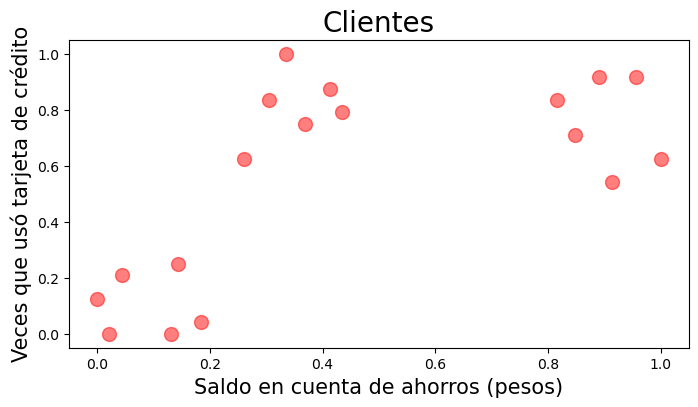

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

clientes = pd.DataFrame({"saldo" : [50000, 45000, 48000, 43500, 47000, 52000, 
                                    20000, 26000, 25000, 23000, 21400, 18000,
                                    8000, 12000, 6000, 14500, 12600, 7000],
                         
                         "transacciones": [25, 20, 16, 23, 25, 18,
                                           23, 22, 24, 21, 27, 18,
                                           8, 3, 6, 4, 9, 3]})
### Escalamos los datos
escalador = MinMaxScaler().fit(clientes.values)

clientes = pd.DataFrame(escalador.transform(clientes.values),
                       columns=["saldo", "transacciones"])

### Vamos a graficar los puntos con una grafica de dispersión.
plt.figure(figsize=(8, 4))

plt.scatter(x=clientes["saldo"],
            y=clientes["transacciones"],
            marker="o", 
            s=100, 
            color="red", 
            alpha=0.5)
### Titulos del la Gráfica
plt.title("Clientes", fontsize=20)
plt.xlabel("Saldo en cuenta de ahorros (pesos)", fontsize=15)
plt.ylabel("Veces que usó tarjeta de crédito", fontsize=15)
plt.show()

### Modelo K-Means

* Los algoritmos de `scikit-learn` como `KMeans` o `MinMaxScaler` no trabajan con DataFrames directamente, sino con `arreglos NumPy` de forma `(n_muestras, n_características)`.
* Si pasaras el DataFrame directamente `(fit(clientes))`, en la mayoría de las versiones recientes de scikit-learn también funciona porque internamente lo convierte a array.
* Pero usar `.values` garantiza que el `objeto es un NumPy array numérico y evita errores en versiones antiguas` o cuando hay columnas con nombres que no son relevantes para el modelo.
* `kmeans.labels_`: es un atributo de nuestro modelo instanciado de K-Means.
* Es un arreglo (array) de longitud igual al número de muestras en tu dataset. Cada elemento indica el número de cluster (etiqueta) asignado a cada punto después de que el algoritmo converge. ***Los valores son enteros entre 0 y K-1 (si K = 7, los labels van de 0 a 6)***.
* Es decir a que cluester pertenecen.
* `clientes["cluster"] = kmeans.labels_`: Esto crea una columna nueva en el DataFrame con el cluster asignado a cada cliente, para luego poder graficar y diferenciar colores según el grupo.
* `kmeans.cluster_centers_`: Coordenadas de los centroides finales de cada cluster.
* `kmeans.inertia_`: Suma de distancias cuadradas de cada punto a su centroide (***medida de qué tan “compactos” son los clusters***).

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


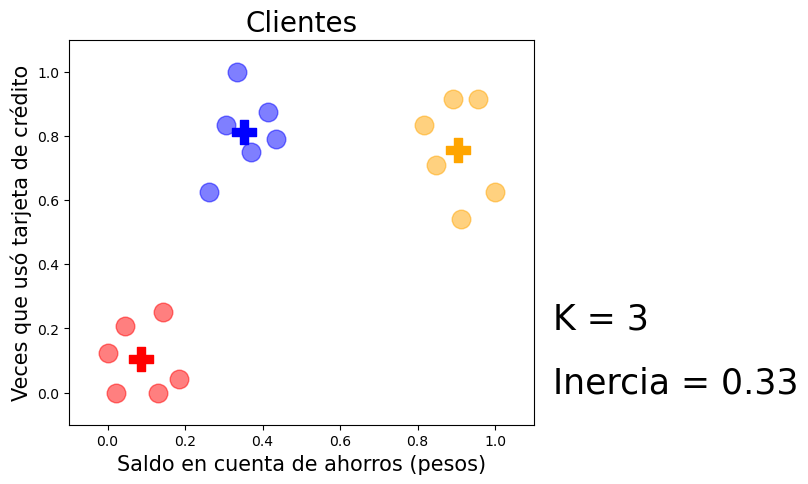

In [8]:
from sklearn.cluster import KMeans

### Instanciamos nuestro modelo y asignamos nuestros 3 Centroides.
kmeans = KMeans(n_clusters=3).fit(clientes.values)

### Clasificación de cluster de los datos.
clientes["cluster"] = kmeans.labels_

# Instrucciones para graficar los clusters 
plt.figure(figsize=(6, 5), dpi=100)
colores = ["red", "blue", "orange", "black", "purple", "pink", "brown"]

### Graficamos y pintamos de colores diferentes cad cluster.
for cluster in range(kmeans.n_clusters):
    ### graficamos los puntos
    plt.scatter(x=clientes[clientes["cluster"] == cluster]["saldo"],
                y=clientes[clientes["cluster"] == cluster]["transacciones"],
                marker="o", s=180, color=colores[cluster], alpha=0.5)
    ### Graficamos las coordenadas Centroide.
    plt.scatter(x=kmeans.cluster_centers_[cluster][0], 
                y=kmeans.cluster_centers_[cluster][1], 
                marker="P", s=280, color=colores[cluster])

plt.title("Clientes", fontsize=20)
plt.xlabel("Saldo en cuenta de ahorros (pesos)", fontsize=15)
plt.ylabel("Veces que usó tarjeta de crédito", fontsize=15)
plt.text(1.15, 0.2, "K = %i" % kmeans.n_clusters, fontsize=25)
plt.text(1.15, 0, "Inercia = %0.2f" % kmeans.inertia_, fontsize=25)
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)    
plt.show()

del clientes["cluster"]

### Método del Codo

* Cálculo del número de Clusters (K).
* El método del codo (Elbow Method) es una técnica muy usada para elegir el número óptimo de clusters (K) al usar algoritmos como K-Means.
* Es una heurística gráfica que ayuda a decidir cuántos clusters elegir en K-Means.
* Se basa en medir la `inercia` o `Within-Cluster Sum of Squares (WCSS)`
* Es la suma de las distancias cuadradas de cada punto a su centroide (mide qué tan compactos son los grupos).
* ¿Cómo funciona?
  - Se entrena el modelo K-Means con diferentes valores de K (por ejemplo, de 1 a 10).
  - Para cada K, se calcula la inercia (kmeans.inertia_ en scikit-learn) y se grafica.
  - La inercia disminuye a medida que aumentamos K (porque más clusters reducen la distancia promedio de los puntos a su centroide).
  - Llega un punto donde la reducción deja de ser significativa y la curva hace una “doblez” o “codo”. Ese punto es el K óptimo, porque a partir de ahí agregar más clusters no mejora mucho el modelo.
* ¿Por qué se usa?
  - Porque elegir K al azar no es buena práctica.
  - El método del codo ayuda a balancear simplicidad y representatividad.
  - K muy pequeño → clusters poco representativos.
  - K muy grande → modelo sobreajustado y sin sentido práctico.
  - Permite justificar de forma visual la elección del número de clusters.
* Limitaciones:
  - Es un criterio heurístico, no exacto.
  - A veces el “codo” no es muy evidente.
  - Hay otros métodos complementarios como el índice de silueta (Silhouette Score) para validar K.

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

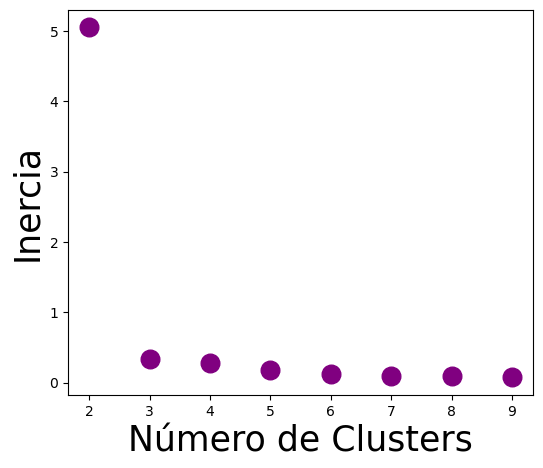

In [9]:
inercias = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k).fit(clientes.values)    
    inercias.append(kmeans.inertia_)

plt.figure(figsize=(6, 5), dpi=100)
plt.scatter(range(2, 10), inercias, marker="o", s=180, color="purple")
plt.xlabel("Número de Clusters", fontsize=25)
plt.ylabel("Inercia", fontsize=25)
plt.show()